In [ ]:
#Demo 1.5 ML Classification examples

Remote data load (seaborn.load_dataset('titanic'), ~891 samples).

Clean preprocessing via a ColumnTransformer (median / most-frequent imputation + one-hot).

Three classical models: Logistic Regression, Random Forest, SVM (RBF with probability=True).

Timing with time.perf_counter() for both fit and predict.

Metrics: accuracy (primary), ROC AUC + curves, confusion matrices.

Plots: accuracy bar, train/predict time bars, ROC curves, per-model confusion matrices.

Sources (docs & datasets)

Seaborn “titanic” dataset (remote load):
https://seaborn.pydata.org/generated/seaborn.load_dataset.html

In [5]:
#df.head()


=== Test Performance Summary ===
              model  test_accuracy  roc_auc  fit_time_sec  predict_time_sec
Logistic Regression       0.771300 0.840986      0.013850          0.001841
      Random Forest       0.744395 0.814548      0.208560          0.027126
          SVM (RBF)       0.605381 0.677007      0.028077          0.003447


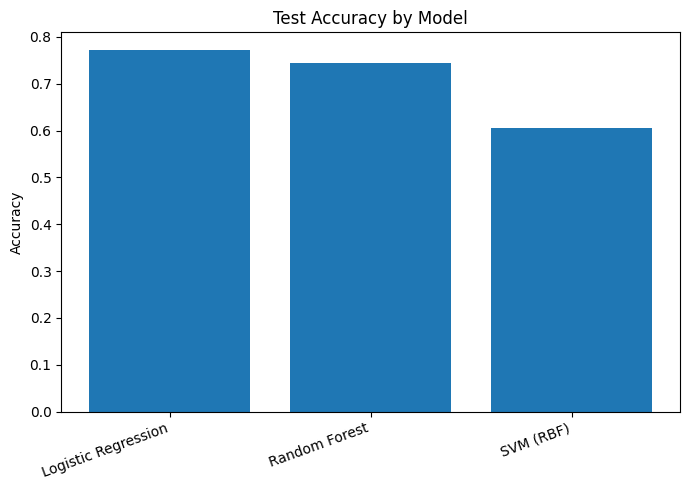

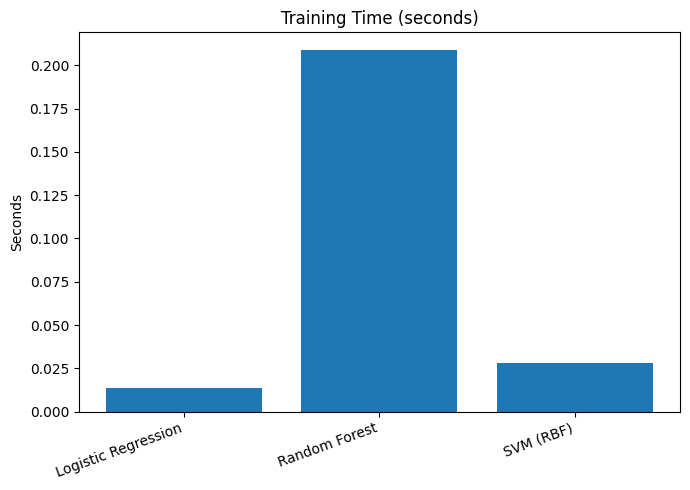

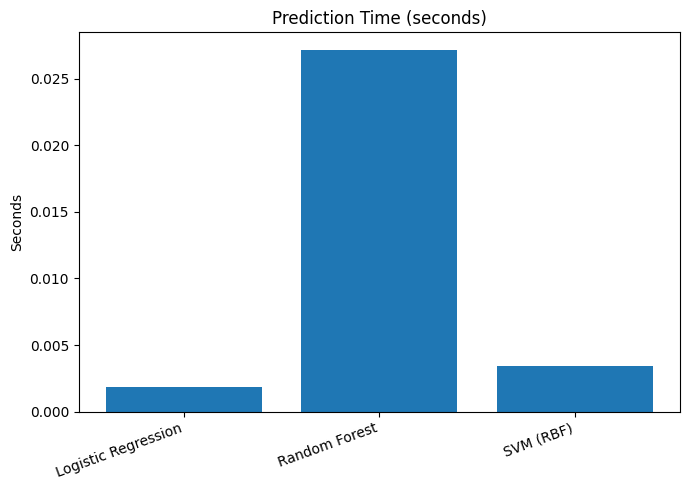

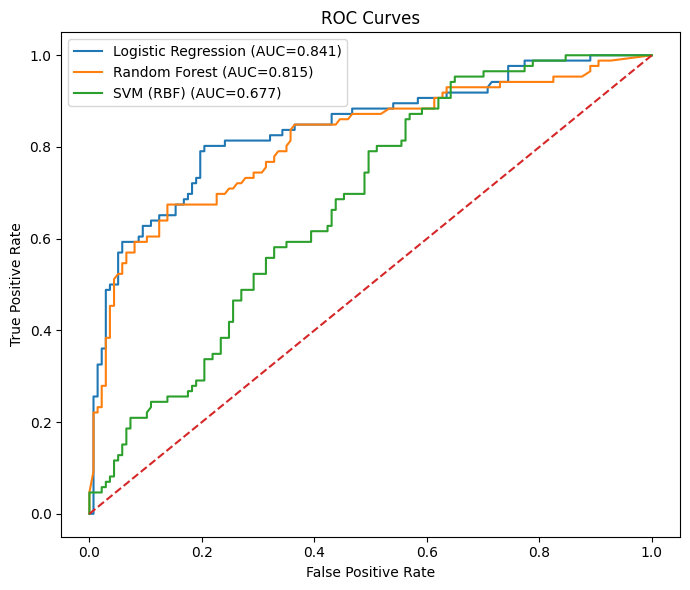

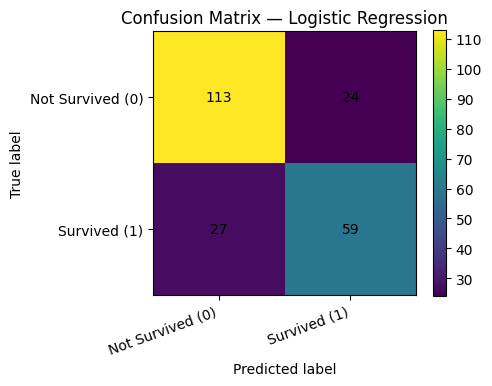

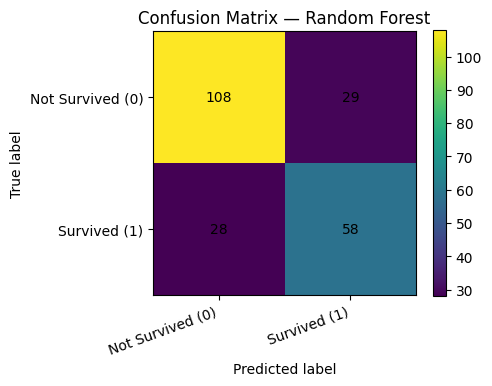

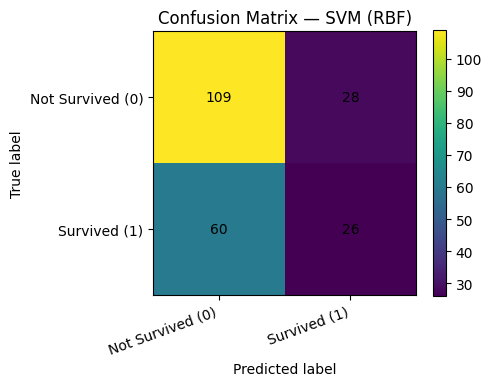

In [2]:
#!/usr/bin/env python3
"""
Demo 1 — Classical ML for classification (Titanic-like, <=1k rows)
- Loads a small dataset remotely (seaborn 'titanic': ~891 rows)
- Trains Logistic Regression, Random Forest, SVM
- Tracks train & test (inference) time
- Reports accuracy and ROC AUC
- Plots: accuracy bar, fit/predict times, ROC curves, confusion matrices
"""

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

# -----------------------------
# 1) Load remote dataset (<=1k)
# -----------------------------
# seaborn.load_dataset downloads from the public seaborn repo (remote source)
import seaborn as sns
df = sns.load_dataset("titanic")  # ~891 rows

# Select a simple, mostly clean subset of useful columns
use_cols = [
    "survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"
]
df = df[use_cols].copy()

# -----------------------------
# 2) Basic cleaning
# -----------------------------
# Define target and features
target = "survived"
y = df[target].astype(int).values
X = df.drop(columns=[target])

# Identify column types
num_cols = ["age", "sibsp", "parch", "fare", "pclass"]
cat_cols = ["sex", "embarked"]

# Preprocess: impute missing (median for nums, most_frequent for cats), one-hot encode cats
numeric_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop",
)

# Train/test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -----------------------------
# 3) Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=None),  # n_jobs not supported here
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
}

results = []
roc_curves = {}  # name -> (fpr, tpr, auc)

# -----------------------------
# 4) Train, time, evaluate
# -----------------------------
for name, base_clf in models.items():
    clf = Pipeline(steps=[("prep", preprocess), ("model", base_clf)])

    # Train time
    t0 = time.perf_counter()
    clf.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    # Predict (class) time
    t1 = time.perf_counter()
    y_pred = clf.predict(X_test)
    pred_time = time.perf_counter() - t1

    acc = accuracy_score(y_test, y_pred)

    # Probabilities for ROC AUC (binary labels 0/1)
    # For SVC with probability=True we can use predict_proba
    # Fallback to decision_function if needed
    try:
        y_score = clf.predict_proba(X_test)[:, 1]
    except Exception:
        y_score = clf.decision_function(X_test)
        # Scale decision_function to [0,1] for AUC comparability if negative values are present
        # (not strictly necessary for ROC AUC, but makes curves consistent if plotted vs. threshold)
        # However, roc_auc_score only needs scores; it’s fine as is.

    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_curves[name] = (fpr, tpr, auc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    results.append(
        {
            "model": name,
            "test_accuracy": acc,
            "roc_auc": auc,
            "fit_time_sec": fit_time,
            "predict_time_sec": pred_time,
            "confusion_matrix": cm,
        }
    )

# -----------------------------
# 5) Summary table
# -----------------------------
summary_df = (
    pd.DataFrame(results)
    .drop(columns=["confusion_matrix"])
    .sort_values(by="test_accuracy", ascending=False)
    .reset_index(drop=True)
)
print("\n=== Test Performance Summary ===")
print(summary_df.to_string(index=False))

# -----------------------------
# 6) Plots
# -----------------------------
plt.figure(figsize=(7, 5))
plt.bar(summary_df["model"], summary_df["test_accuracy"])
plt.title("Test Accuracy by Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(summary_df["model"], summary_df["fit_time_sec"])
plt.title("Training Time (seconds)")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(summary_df["model"], summary_df["predict_time_sec"])
plt.title("Prediction Time (seconds)")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
for r in results:
    cm = r["confusion_matrix"]
    name = r["model"]
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix — {name}")
    plt.colorbar()
    tick_marks = np.arange(2)
    classes = ["Not Survived (0)", "Survived (1)"]
    plt.xticks(tick_marks, classes, rotation=20, ha="right")
    plt.yticks(tick_marks, classes)
    # annotate cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
            )
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


In [3]:
############################################################################################################################################

In [4]:
############################################################################################################################################

In [6]:
#############Second Demo 1.6 ML Regression cases

In [5]:
#pip install -U scikit-learn

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



=== Test Performance Summary ===
            model       R2      MAE     RMSE  fit_time_sec  predict_time_sec
        SVR (RBF) 0.919809 1.652667 2.133896      0.005498          0.001844
    Random Forest 0.884844 1.722190 2.557144      0.159805          0.026140
Linear Regression 0.843049 2.343843 2.985333      0.002987          0.001289


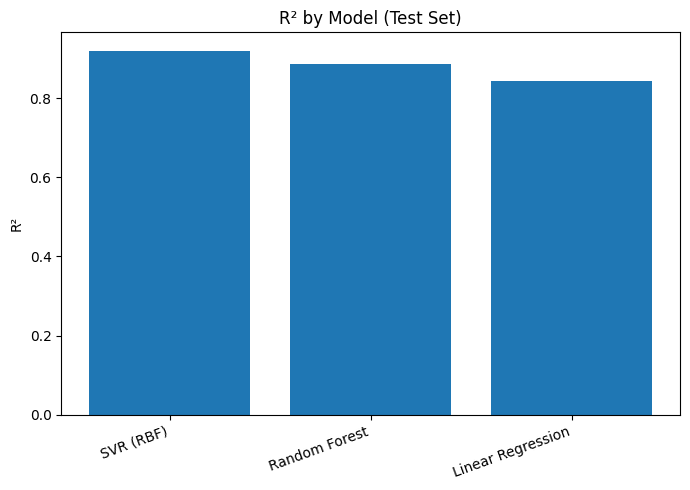

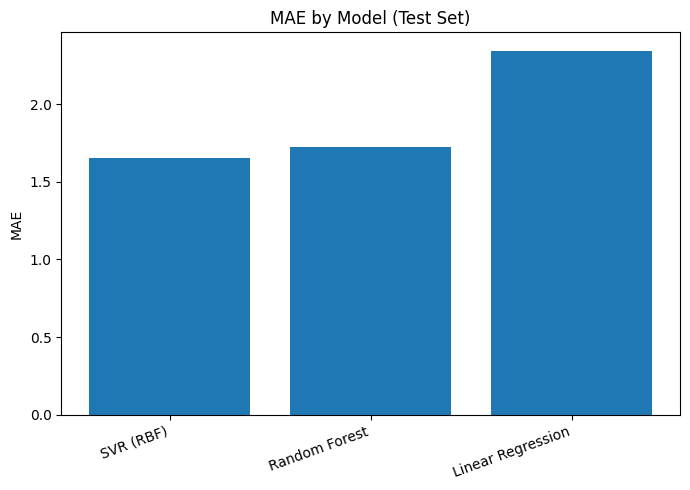

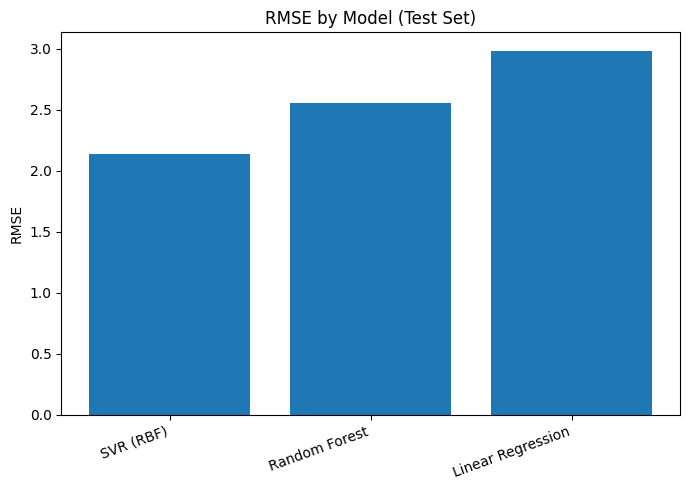

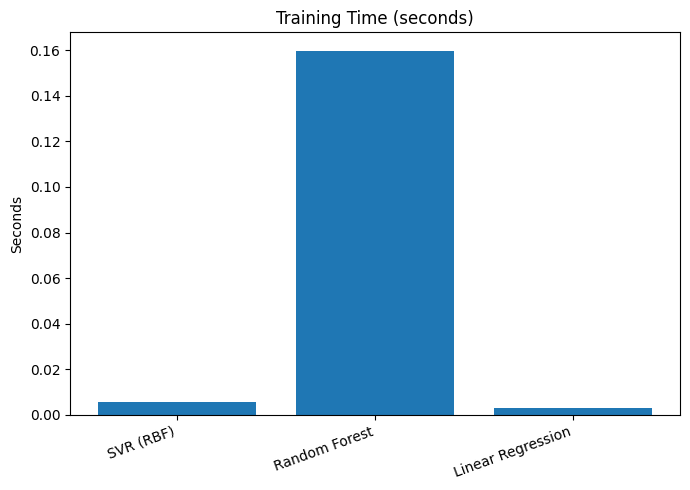

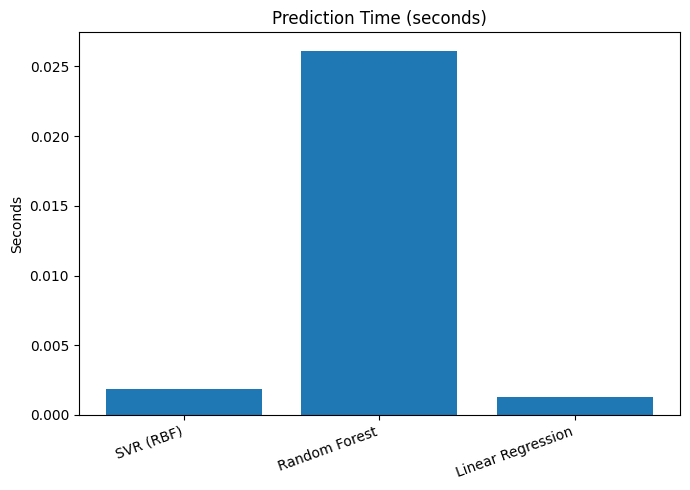

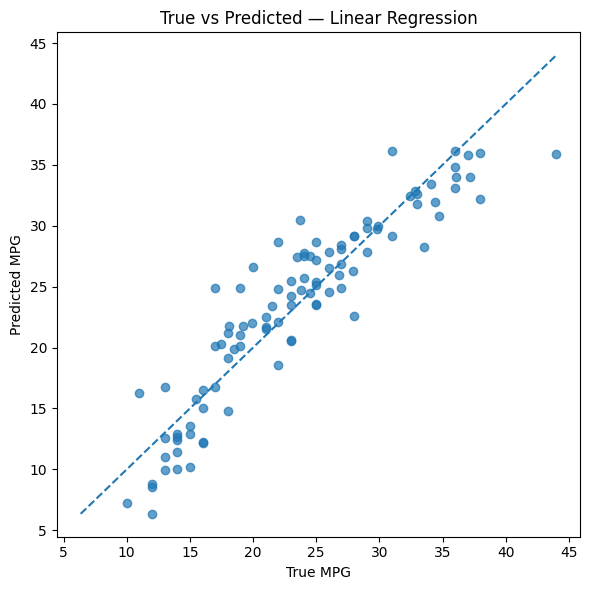

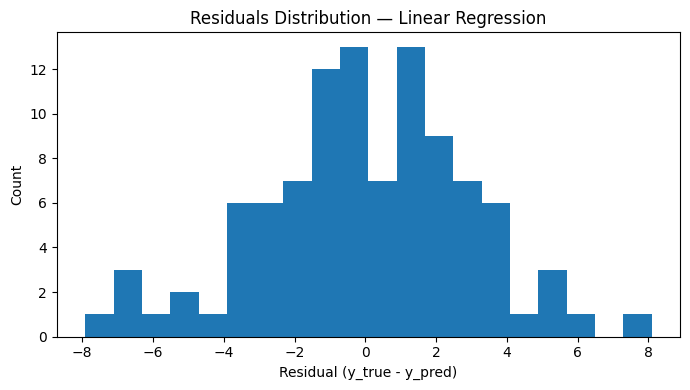

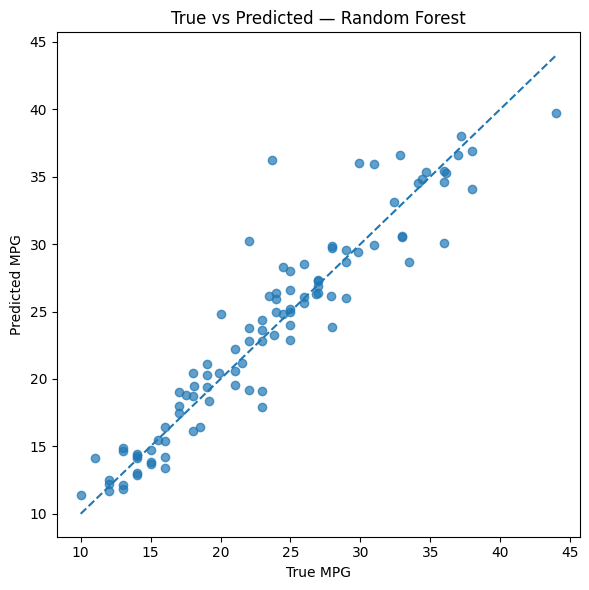

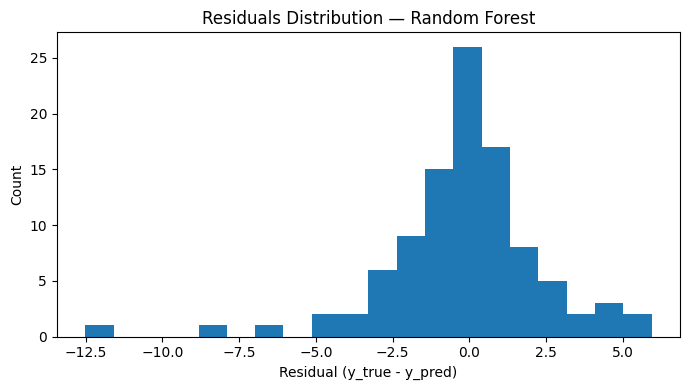

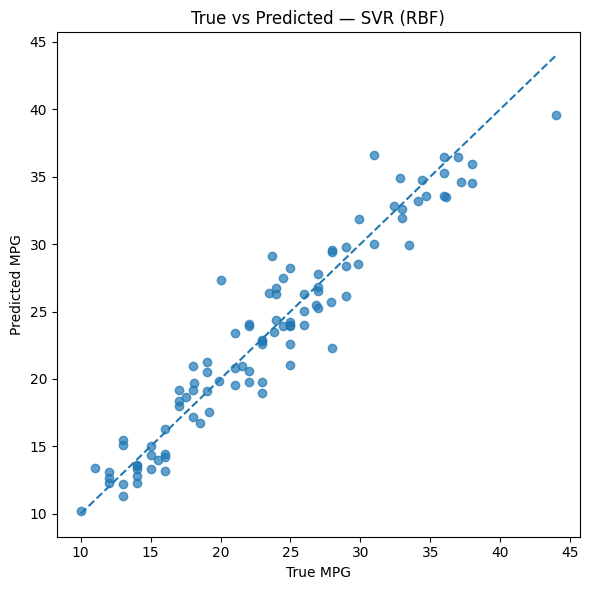

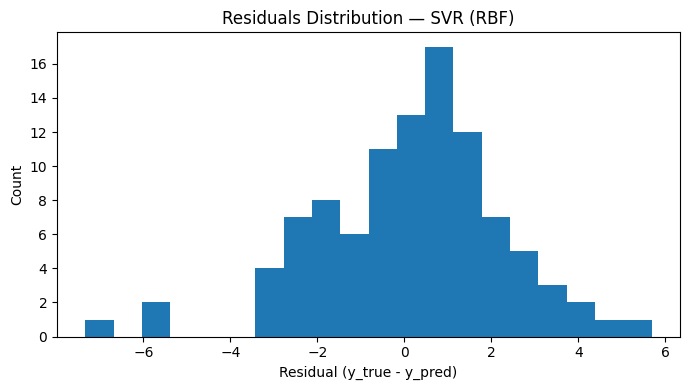

In [8]:
#!/usr/bin/env python3
"""
Demo 2 — Classical ML for regression (mpg, ~398 rows)
- Remote load via seaborn.load_dataset('mpg')
- Models: Linear Regression, Random Forest, SVR (RBF)
- Track train & predict time
- Metrics: R^2, MAE, RMSE
- Plots: metrics bars, y_true vs y_pred, residuals
"""

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# -----------------------------
# 1) Load remote dataset (<=1k)
# -----------------------------
df = sns.load_dataset("mpg")  # ~398 rows

# Target and features
target = "mpg"
X = df.drop(columns=[target, "name"])  # drop text field
y = df[target].values

# Identify columns
cat_cols = ["origin"]
num_cols = [c for c in X.columns if c not in cat_cols]

# -----------------------------
# 2) Preprocessing
# -----------------------------
numeric_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop",
)

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------
# 4) Models
# -----------------------------
models = {
    "Linear Regression": Pipeline(
        steps=[("prep", preprocess), ("model", LinearRegression())]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("prep", preprocess),
            ("model", RandomForestRegressor(
                n_estimators=400, random_state=42, n_jobs=-1
            )),
        ]
    ),
    "SVR (RBF)": Pipeline(
        steps=[
            ("prep", preprocess),
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.2)),
        ]
    ),
}

# -----------------------------
# 5) Train, time, evaluate
# -----------------------------
rows = []
pred_store = {}

for name, pipe in models.items():
    # Fit time
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    # Predict time
    t1 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    pred_time = time.perf_counter() - t1

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # <-- manual RMSE (works everywhere)

    rows.append(
        {
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "fit_time_sec": fit_time,
            "predict_time_sec": pred_time,
        }
    )
    pred_store[name] = (y_pred, y_test)

results = pd.DataFrame(rows).sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n=== Test Performance Summary ===")
print(results.to_string(index=False))

# -----------------------------
# 6) Plots
# -----------------------------
plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["R2"])
plt.title("R² by Model (Test Set)")
plt.ylabel("R²")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["MAE"])
plt.title("MAE by Model (Test Set)")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["RMSE"])
plt.title("RMSE by Model (Test Set)")
plt.ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["fit_time_sec"])
plt.title("Training Time (seconds)")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["predict_time_sec"])
plt.title("Prediction Time (seconds)")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# y_true vs y_pred + residuals
for name, (y_pred, y_true) in pred_store.items():
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    plt.xlabel("True MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"True vs Predicted — {name}")
    plt.tight_layout()
    plt.show()

    residuals = y_true - y_pred
    plt.figure(figsize=(7, 4))
    plt.hist(residuals, bins=20)
    plt.title(f"Residuals Distribution — {name}")
    plt.xlabel("Residual (y_true - y_pred)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [ ]:
############################################################################################################################################

In [ ]:
############################################################################################################################################

In [ ]:
##### Third Demo: 1.8 Heavy classification task 

In [10]:
#python demo3_cvd2022_classification.py --csv heart_2022_no_nans.csv --target HadHeartAttack --sample_rows 50000
